  Depth_Percent Total_ORFs novel annotated uORF dORF Overlap_uORF Overlap_dORF
1            10      51414 24336     19337 4719 1227         1068          586
2            20      56911 27224     19728 6162 1716         1334          548
3            30      60309 28960     19892 7088 2139         1442          563
4            40      62841 30319     19949 7762 2406         1568          584
5            50      64796 31293     20057 8291 2674         1649          560
6            60      66321 32054     20069 8715 2918         1692          594
  internal
1      141
2      199
3      225
4      253
5      272
6      279


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


[1] "绘图完成！图片已保存。"


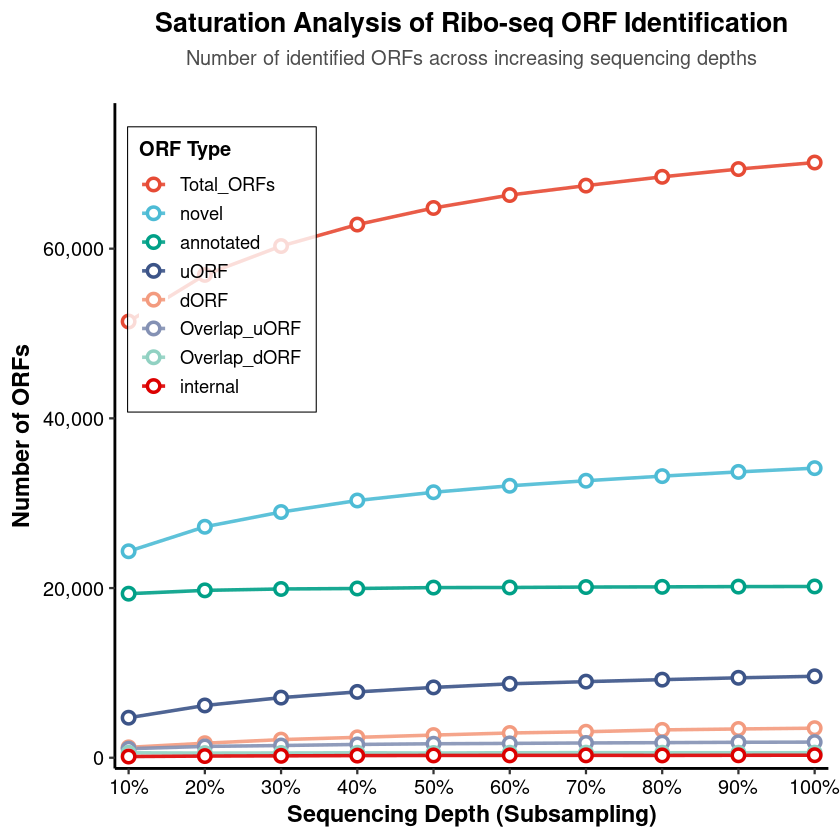

In [1]:
library(ggplot2)
library(tidyr)
library(ggsci)   # 提供了 Nature, Lancet 等期刊的经典配色
library(ggrepel) # 用于智能调整标签位置
library(scales)  # 用于坐标轴格式化

# ================= 1. 读取数据 =================
# 请修改为你的实际文件路径
csv_file <- "/home/user/data3/lit/project/sORFs/01-ribo-seq/analysis/20251022_custom_fa_gtf/processed/saturation_analysis/saturation_stats.csv"

# 读取数据
df <- read.csv(csv_file, check.names = FALSE)

# 检查数据
print(head(df))

# ================= 2. 数据清洗 (宽表转长表) =================
# ggplot2 需要长格式数据。我们将除了 Depth_Percent 以外的所有列都转换为 "Type" 和 "Count"
# 假设第一列是 Depth_Percent，其他都是数值列
plot_data <- df %>%
  pivot_longer(
    cols = -Depth_Percent, 
    names_to = "ORF_Type", 
    values_to = "Count"
  )

# 确保 Depth_Percent 是数值型
plot_data$Depth_Percent <- as.numeric(plot_data$Depth_Percent)

# 可选：如果你不想画 Total_ORFs (因为它数值太大，会压缩其他线条)，可以取消下面这行的注释
# plot_data <- plot_data[plot_data$ORF_Type != "Total_ORFs", ]

# 为了图例排序美观，可以让 Total 排在最前或最后，这里按数量降序排列 Factor
plot_data$ORF_Type <- factor(plot_data$ORF_Type, 
                             levels = unique(plot_data$ORF_Type[order(plot_data$Count, decreasing = TRUE)]))

# ================= 3. 绘图 (Publication Ready Style) =================

p <- ggplot(plot_data, aes(x = Depth_Percent, y = Count, group = ORF_Type, color = ORF_Type)) +
  
  # 1. 绘制线条和点
  geom_line(linewidth = 1, alpha = 0.9) +  # 线条稍粗，透明度微调
  geom_point(size = 2.5, shape = 21, fill = "white", stroke = 1.5) + # 空心点，显得更精致
  
  # 2. 顶级期刊配色方案 (推荐 NPG - Nature Publishing Group 风格)
  scale_color_npg() + 
  # 如果类型特别多超过10种，可以用 scale_color_igv() 或 manual 手动指定
  
  # 3. 坐标轴设置
  scale_x_continuous(
    breaks = seq(10, 100, 10), 
    labels = function(x) paste0(x, "%"),
    expand = c(0.02, 0) # 减少X轴左右留白
  ) +
  scale_y_continuous(
    labels = comma, # 使用逗号分隔千分位 (需 library scales)
    expand = expansion(mult = c(0.02, 0.1)) # Y轴上方多留一点空间给标签
  ) +
  
  # 4. 标签与标题
  labs(
    title = "Saturation Analysis of Ribo-seq ORF Identification",
    subtitle = "Number of identified ORFs across increasing sequencing depths",
    x = "Sequencing Depth (Subsampling)",
    y = "Number of ORFs",
    color = "ORF Type"
  ) +
  
  # 5. 主题设置 (Classic 是最常用的期刊风格：白底、黑轴、无网格)
  theme_classic(base_size = 14) + 
  
  theme(
    # 字体设置 (Arial/Helvetica 是标准)
    text = element_text(family = "sans"), 
    
    # 标题样式
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.subtitle = element_text(size = 12, color = "gray30", hjust = 0.5, margin = margin(b = 20)),
    
    # 坐标轴样式
    axis.title = element_text(face = "bold", size = 14),
    axis.text = element_text(size = 12, color = "black"),
    axis.line = element_line(linewidth = 0.8), # 加粗坐标轴线
    
    # 图例样式 (放图内右上角通常更紧凑专业，如果挡住线条可改为 'right')
    legend.position = c(0.15, 0.75), # 坐标 0-1 之间调整
    legend.background = element_rect(fill = alpha("white", 0.8), color = "black", size = 0.3),
    legend.title = element_text(face = "bold", size = 12),
    legend.text = element_text(size = 11)
  )

# ================= 4. (可选) 添加末端直接标签 =================
# 这种风格在 Nature/Science 中很常见，不使用图例，直接在曲线末端标字
# 如果线条较多，建议保留图例；如果线条少，可以用下面的代码替代图例

# p <- p + geom_text_repel(
#   data = subset(plot_data, Depth_Percent == 100),
#   aes(label = ORF_Type),
#   nudge_x = 5,
#   direction = "y",
#   hjust = 0,
#   segment.size = 0.2
# ) +
# theme(legend.position = "none") +
# scale_x_continuous(limits = c(10, 115), breaks = seq(10, 100, 10)) # 扩展X轴放文字



print("绘图完成！图片已保存。")
print(p)

In [2]:
# ================= 5. 保存图片 =================
# 保存为 PDF (矢量图，投稿首选) 和 PNG (预览用)
ggsave("/home/user/data3/lit/project/sORFs/01-ribo-seq/analysis/20251022_custom_fa_gtf/processed/saturation_analysis/Saturation_Curve_Publication.pdf", p, width = 8, height = 6, dpi = 300)